# Lib

In [1]:
!pip uninstall -y torch torchvision torchaudio

!pip install --pre torch torchvision torchaudio \
  --index-url https://download.pytorch.org/whl/nightly/cu128

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 41.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 64.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 84.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.5/832.5 MB 1.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.2/292.2 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.3 MB/s eta

In [2]:
import os
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample


from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [3]:
import torchvision
print(torchvision.__version__)

0.27.0.dev20260407+cu128


In [4]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.12.0.dev20260407+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4
capability: (7, 5)


# Data

In [12]:
dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")

# Image
image_dir = dataset_dir / "images" / "images"
# image_dir = dataset_dir / "image_crop" / "image_crop"

# Annotation
annotation_path = r"/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760/labels/annotations.csv"
# annotation_path = dataset_dir /"image_crop"/"image_crop"/ "cropped_annotations.csv"

annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
0,train_00000.jpeg,2448,3264,1301,1546,1641,2096,albopictus
1,train_00001.jpeg,3024,4032,900,1897,1950,2990,albopictus
2,train_00002.jpeg,768,1024,220,58,659,808,albopictus
3,train_00003.jpeg,3456,4608,1169,2364,1586,2826,albopictus
4,train_00004.jpeg,1024,1365,129,231,697,1007,culex


In [13]:
annotations.columns

Index(['img_fName', 'img_w', 'img_h', 'bbx_xtl', 'bbx_ytl', 'bbx_xbr',
       'bbx_ybr', 'class_label'],
      dtype='object')

In [14]:
annotations.shape

(10357, 8)

In [15]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10357
class_label
albopictus            4612
culex                 4563
culiseta               622
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000.jpeg,albopictus
1,train_00001.jpeg,albopictus
2,train_00002.jpeg,albopictus
3,train_00003.jpeg,albopictus
4,train_00004.jpeg,culex


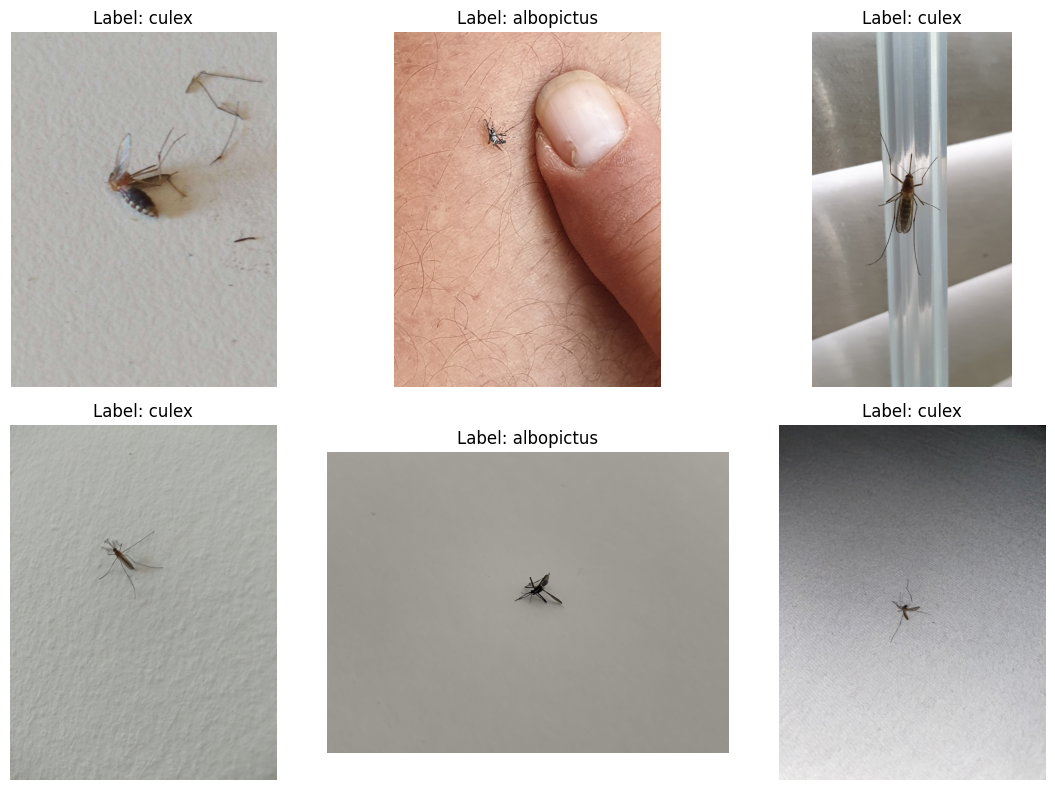

In [42]:
# number of images to show
num_images = 6

sample_df = annotations.sample(num_images, random_state=760)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = image_dir / row["img_fName"]   # adjust column name if needed
    
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {row['class_label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing

In [17]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

In [18]:
def oversample_dataframe(df, label_col, random_state=42):
    max_count = df[label_col].value_counts().max()
    balanced = []

    for label in df[label_col].unique():
        subset = df[df[label_col] == label]
        upsampled = resample(
            subset,
            replace=True,
            n_samples=max_count,
            random_state=random_state
        )
        balanced.append(upsampled)

    return pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)


from imblearn.over_sampling import ADASYN
import pandas as pd

def adasyn_resample_dataframe(df, label_col, random_state=42):
    """
    Resample a DataFrame using ADASYN to balance classes.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        label_col (str): Name of the target column
        random_state (int): Random seed for reproducibility
        
    Returns:
        pd.DataFrame: Balanced DataFrame with synthetic samples
    """
    X = df.drop(columns=[label_col])
    y = df[label_col]

    # Initialize ADASYN
    adasyn = ADASYN(random_state=random_state)

    # Fit and resample
    X_res, y_res = adasyn.fit_resample(X, y)

    # Reconstruct DataFrame
    df_resampled = pd.DataFrame(X_res, columns=X.columns)
    df_resampled[label_col] = y_res

    # Shuffle the DataFrame
    return df_resampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

In [19]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)


#Oversampling method
# train_df = oversample_dataframe(train_df, label_col="label_id")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain label distribution after oversampling:")
print(train_df["label_id"].value_counts())

Train: 7249
Val: 1554
Test: 1554

Train label distribution after oversampling:
label_id
1    3228
3    3194
4     435
5     300
2      59
0      33
Name: count, dtype: int64


In [20]:
# train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
#     lambda x: x.sample(min(len(x), 50), random_state=42)
# ).reset_index(drop=True)

# val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
#     lambda x: x.sample(min(len(x), 20), random_state=42)
# ).reset_index(drop=True)

# test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
#     lambda x: x.sample(min(len(x), 20), random_state=42)
# ).reset_index(drop=True)

# print("Subset Train:", len(train_subset_df))
# print("Subset Val:", len(val_subset_df))
# print("Subset Test:", len(test_subset_df))

# Modeling

## ENV

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Using: cuda
GPU: Tesla T4
Capability: (7, 5)


## Transform

In [22]:
image_size = 224

# train_transform = transforms.Compose([
#     transforms.Resize((image_size, image_size)),
#     transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0), ratio=(0.75, 1.33)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomVerticalFlip(p=0.2),
#     transforms.RandomRotation(degrees=15),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# eval_transform = transforms.Compose([
#     transforms.Resize((image_size, image_size)),
#     transforms.CenterCrop(image_size),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])


train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Dataset

In [23]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.image_dir / row["img_fName"]
        image = Image.open(image_path).convert("RGB")
        label = int(row["label_id"])

        if self.transform:
            image = self.transform(image)

        return image, label


In [24]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Baseline modeling 
- Model builder and call out

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import (
    ResNet50_Weights,
    ResNet101_Weights,
    EfficientNet_V2_L_Weights,
    EfficientNet_B0_Weights,
    MobileNet_V2_Weights,
)

def build_model(model_name, num_classes, freeze_backbone=True):
    model_name = model_name.lower()

    if model_name == "resnet50":
        model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        backbone_params = [p for name, p in model.named_parameters() if not name.startswith("fc.")]

    elif model_name == "resnet101":
        model = models.resnet101(weights=ResNet101_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        backbone_params = [p for name, p in model.named_parameters() if not name.startswith("fc.")]

    elif model_name == "efficientnet_v2_l":
        model = models.efficientnet_v2_l(weights=EfficientNet_V2_L_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        backbone_params = model.features.parameters()

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        backbone_params = model.features.parameters()

    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        backbone_params = model.features.parameters()

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    if freeze_backbone:
        for param in backbone_params:
            param.requires_grad = False

    return model

# Training process

## Training 1 model builder

- Number of epochs: 30
- Lr = 1e-5
- Transfer learning
- criterion: CrossEntropy loss
- optimizer: Adam

In [32]:
def train_one_model(
    model_name,
    train_loader,
    val_loader,
    num_classes,
    class_names,
    device,
    output_dir,
    num_epochs=30,
    patience=5,
    lr=1e-5,
    freeze_backbone=True
):
    print(f"\n\n==============================")
    print(f"Start training: {model_name}")
    print(f"==============================")

    model = build_model(
        model_name=model_name,
        num_classes=num_classes,
        freeze_backbone=freeze_backbone
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_val_loss = float("inf")
    early_stop_counter = 0
    history = []

    print("Selected device:", device)
    print("Model device:", next(model.parameters()).device)

    for epoch in range(num_epochs):
        print(f"\n===== {model_name} | Epoch {epoch + 1}/{num_epochs} =====")

        # =========================
        # Training
        # =========================
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            if batch_idx == 0:
                print("Before move:")
                print("  images device:", images.device)
                print("  labels device:", labels.device)

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if batch_idx == 0:
                print("After move:")
                print("  images device:", images.device)
                print("  labels device:", labels.device)
                print("  model device:", next(model.parameters()).device)

                if torch.cuda.is_available():
                    print(
                        "  GPU memory allocated:",
                        torch.cuda.memory_allocated() / 1024**2,
                        "MB"
                    )
                    print(
                        "  GPU memory reserved:",
                        torch.cuda.memory_reserved() / 1024**2,
                        "MB"
                    )

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            if batch_idx % 10 == 0:
                print(
                    f"[Train] {model_name} | "
                    f"Epoch {epoch + 1} Batch {batch_idx}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f}"
                )

        train_loss /= train_total
        train_acc = train_correct / train_total

        # =========================
        # Validation
        # =========================
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, (images, labels) in enumerate(val_loader):
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                if batch_idx % 10 == 0:
                    print(
                        f"[Val] {model_name} | "
                        f"Epoch {epoch + 1} Batch {batch_idx}/{len(val_loader)} | "
                        f"Loss: {loss.item():.4f}"
                    )

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(
            f"{model_name} | Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # =========================
        # Save history
        # =========================
        epoch_result = {
            "model_name": model_name,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_loss_so_far": min(best_val_loss, val_loss),
            "early_stop_counter": early_stop_counter,
        }

        history.append(epoch_result)

        history_path = output_dir / f"{model_name}_training_history.csv"
        pd.DataFrame(history).to_csv(history_path, index=False)

        # =========================
        # Save checkpoint every epoch
        # =========================
        checkpoint_path = output_dir / f"{model_name}_checkpoint_epoch_{epoch + 1}.pth"

        torch.save({
            "model_name": model_name,
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "class_names": class_names,
        }, checkpoint_path)

        print(f"Saved checkpoint to: {checkpoint_path}")

        # =========================
        # Save best model
        # =========================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0

            best_model_path = output_dir / f"best_{model_name}.pth"

            torch.save({
                "model_name": model_name,
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "class_names": class_names,
            }, best_model_path)

            print(f"Best model updated and saved to: {best_model_path}")

        else:
            early_stop_counter += 1
            print(
                f"No improvement. Early stop counter: "
                f"{early_stop_counter}/{patience}"
            )

        # update latest history with new early stop counter
        history[-1]["early_stop_counter"] = early_stop_counter
        pd.DataFrame(history).to_csv(history_path, index=False)

        if early_stop_counter >= patience:
            print(f"Early stopping triggered for {model_name}.")
            break

    # =========================
    # Final benchmark result
    # =========================
    history_df = pd.DataFrame(history)

    best_row = history_df.loc[history_df["val_loss"].idxmin()]

    benchmark_result = {
        "model_name": model_name,
        "best_epoch": int(best_row["epoch"]),
        "best_train_loss": float(best_row["train_loss"]),
        "best_train_acc": float(best_row["train_acc"]),
        "best_val_loss": float(best_row["val_loss"]),
        "best_val_acc": float(best_row["val_acc"]),
        "total_epochs_trained": len(history_df),
        "early_stopped": early_stop_counter >= patience,
        "best_model_path": str(output_dir / f"best_{model_name}.pth"),
        "history_path": str(history_path),
    }

    print(f"Training completed for {model_name}.")
    print("Best validation accuracy:", benchmark_result["best_val_acc"])

    return benchmark_result, history_df

In [34]:
output_dir = Path("/kaggle/working/")
output_dir.mkdir(parents=True, exist_ok=True)

model_names = [
    "resnet50",
    "resnet101",
    "efficientnet_v2_l",
    "efficientnet_b0",
    "mobilenet_v2",
]

all_benchmarks = []

for model_name in model_names:
    benchmark_result, history_df = train_one_model(
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=num_classes,
        class_names=class_names,
        device=device,
        output_dir=output_dir,
        num_epochs=30,
        patience=5,
        lr=1e-5,
        freeze_backbone=True
    )

    all_benchmarks.append(benchmark_result)

# =========================
# Save combined benchmark
# =========================

benchmark_df = pd.DataFrame(all_benchmarks)

benchmark_path = output_dir / "model_benchmark_summary.csv"
benchmark_df.to_csv(benchmark_path, index=False)

print("\nAll model training completed.")
print(f"Benchmark summary saved to: {benchmark_path}")

benchmark_df



Start training: resnet50
Selected device: cuda
Model device: cuda:0

===== resnet50 | Epoch 1/1 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 693.12841796875 MB
  GPU memory reserved: 1136.0 MB
[Train] resnet50 | Epoch 1 Batch 0/227 | Loss: 1.8377
[Train] resnet50 | Epoch 1 Batch 10/227 | Loss: 1.8129
[Train] resnet50 | Epoch 1 Batch 20/227 | Loss: 1.7824
[Train] resnet50 | Epoch 1 Batch 30/227 | Loss: 1.7687
[Train] resnet50 | Epoch 1 Batch 40/227 | Loss: 1.7335
[Train] resnet50 | Epoch 1 Batch 50/227 | Loss: 1.7741
[Train] resnet50 | Epoch 1 Batch 60/227 | Loss: 1.7346
[Train] resnet50 | Epoch 1 Batch 70/227 | Loss: 1.6841
[Train] resnet50 | Epoch 1 Batch 80/227 | Loss: 1.6731
[Train] resnet50 | Epoch 1 Batch 90/227 | Loss: 1.6343
[Train] resnet50 | Epoch 1 Batch 100/227 | Loss: 1.6881
[Train] resnet50 | Epoch 1 Batch 110/227 | Loss: 1.6831
[Train] resnet50 | Ep

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] resnet50 | Epoch 1 Batch 0/49 | Loss: 1.5045
[Val] resnet50 | Epoch 1 Batch 10/49 | Loss: 1.5143
[Val] resnet50 | Epoch 1 Batch 20/49 | Loss: 1.4591
[Val] resnet50 | Epoch 1 Batch 30/49 | Loss: 1.5354
[Val] resnet50 | Epoch 1 Batch 40/49 | Loss: 1.4159
resnet50 | Epoch 1/1 | Train Loss: 1.6463 | Train Acc: 0.3923 | Val Loss: 1.5057 | Val Acc: 0.4929
Saved checkpoint to: /kaggle/working/resnet50_checkpoint_epoch_1.pth
Best model updated and saved to: /kaggle/working/best_resnet50.pth
Training completed for resnet50.
Best validation accuracy: 0.4929214929214929


Start training: resnet101
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 231MB/s] 


Selected device: cuda
Model device: cuda:0

===== resnet101 | Epoch 1/1 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 765.8017578125 MB
  GPU memory reserved: 1172.0 MB
[Train] resnet101 | Epoch 1 Batch 0/227 | Loss: 1.8639
[Train] resnet101 | Epoch 1 Batch 10/227 | Loss: 1.8459
[Train] resnet101 | Epoch 1 Batch 20/227 | Loss: 1.8052
[Train] resnet101 | Epoch 1 Batch 30/227 | Loss: 1.8441
[Train] resnet101 | Epoch 1 Batch 40/227 | Loss: 1.7062
[Train] resnet101 | Epoch 1 Batch 50/227 | Loss: 1.7617
[Train] resnet101 | Epoch 1 Batch 60/227 | Loss: 1.6859
[Train] resnet101 | Epoch 1 Batch 70/227 | Loss: 1.6855
[Train] resnet101 | Epoch 1 Batch 80/227 | Loss: 1.6278
[Train] resnet101 | Epoch 1 Batch 90/227 | Loss: 1.5958
[Train] resnet101 | Epoch 1 Batch 100/227 | Loss: 1.6549
[Train] resnet101 | Epoch 1 Batch 110/227 | Loss: 1.5879
[Train] resnet101 | Epoch 1 Batch 12

...

Selected device: cuda
Model device: cuda:0

===== mobilenet_v2 | Epoch 1/1 =====


Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 611.53076171875 MB
  GPU memory reserved: 1830.0 MB
[Train] mobilenet_v2 | Epoch 1 Batch 0/227 | Loss: 1.7631
[Train] mobilenet_v2 | Epoch 1 Batch 10/227 | Loss: 1.6929
[Train] mobilenet_v2 | Epoch 1 Batch 20/227 | Loss: 1.6965
[Train] mobilenet_v2 | Epoch 1 Batch 30/227 | Loss: 1.7072
[Train] mobilenet_v2 | Epoch 1 Batch 40/227 | Loss: 1.6425
[Train] mobilenet_v2 | Epoch 1 Batch 50/227 | Loss: 1.6763
[Train] mobilenet_v2 | Epoch 1 Batch 60/227 | Loss: 1.6669
[Train] mobilenet_v2 | Epoch 1 Batch 70/227 | Loss: 1.5734
[Train] mobilenet_v2 | Epoch 1 Batch 80/227 | Loss: 1.6091
[Train] mobilenet_v2 | Epoch 1 Batch 90/227 | Loss: 1.6108
[Train] mobilenet_v2 | Epoch 1 Batch 100/227 | Loss: 1.6180
[Train] mobilenet_v2 | Epoch 1 Batch 110/227 | Loss: 1.5872
[Train] mobilenet_v2 | Epoch 1 Batch 120/227 | Loss: 1.6016
[Train] mobilenet

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] mobilenet_v2 | Epoch 1 Batch 0/49 | Loss: 1.4549
[Val] mobilenet_v2 | Epoch 1 Batch 10/49 | Loss: 1.4324
[Val] mobilenet_v2 | Epoch 1 Batch 20/49 | Loss: 1.3973
[Val] mobilenet_v2 | Epoch 1 Batch 30/49 | Loss: 1.4981
[Val] mobilenet_v2 | Epoch 1 Batch 40/49 | Loss: 1.3474
mobilenet_v2 | Epoch 1/1 | Train Loss: 1.5787 | Train Acc: 0.3992 | Val Loss: 1.4334 | Val Acc: 0.4813
Saved checkpoint to: /kaggle/working/mobilenet_v2_checkpoint_epoch_1.pth
Best model updated and saved to: /kaggle/working/best_mobilenet_v2.pth
Training completed for mobilenet_v2.
Best validation accuracy: 0.48133848133848134

All model training completed.
Benchmark summary saved to: /kaggle/working/model_benchmark_summary.csv


,model_name,best_epoch,best_train_loss,best_train_acc,best_val_loss,best_val_acc,total_epochs_trained,early_stopped,best_model_path,history_path
0,resnet50,1,1.646332,0.392330,1.505734,0.492921,1,False,/kaggle/working/best_resnet50.pth,/kaggle/working/resnet50_training_history.csv
1,resnet101,1,1.597556,0.383087,1.447132,0.455598,1,False,/kaggle/working/best_resnet101.pth,/kaggle/working/resnet101_training_history.csv
2,efficientnet_v2_l,1,1.604786,0.308318,1.413558,0.465894,1,False,/kaggle/working/best_efficientnet_v2_l.pth,/kaggle/working/efficientnet_v2_l_training_his...
3,efficientnet_b0,1,1.637340,0.344461,1.530111,0.413127,1,False,/kaggle/working/best_efficientnet_b0.pth,/kaggle/working/efficientnet_b0_training_histo...
4,mobilenet_v2,1,1.578740,0.399227,1.433390,0.481338,1,False,/kaggle/working/best_mobilenet_v2.pth,/kaggle/working/mobilenet_v2_training_history.csv


## Convergence behavior

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_convergence(model_name, output_dir, max_epochs=30):
    output_dir = Path(output_dir)

    history_path = output_dir / f"{model_name}_training_history.csv"
    df = pd.read_csv(history_path)

    # limit to first N epochs if needed
    df = df[df["epoch"] <= max_epochs]

    # ===== Loss plot =====
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Convergence (Loss) - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    loss_path = output_dir / f"{model_name}_convergence_loss.png"
    plt.savefig(loss_path, dpi=300)
    plt.show()

    # ===== Accuracy plot =====
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["train_acc"], label="Train Accuracy")
    plt.plot(df["epoch"], df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Convergence (Accuracy) - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    acc_path = output_dir / f"{model_name}_convergence_accuracy.png"
    plt.savefig(acc_path, dpi=300)
    plt.show()

    print(f"Saved plots for {model_name}")


def compare_convergence(model_names, output_dir, max_epochs=30):
    output_dir = Path(output_dir)

    plt.figure(figsize=(12, 6))

    for model_name in model_names:
        df = pd.read_csv(output_dir / f"{model_name}_training_history.csv")
        df = df[df["epoch"] <= max_epochs]

        plt.plot(df["epoch"], df["val_loss"], label=model_name)

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Convergence Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(output_dir / "compare_val_loss.png", dpi=300)
    plt.show()


    plt.figure(figsize=(12, 6))

    for model_name in model_names:
        df = pd.read_csv(output_dir / f"{model_name}_training_history.csv")
        df = df[df["epoch"] <= max_epochs]

        plt.plot(df["epoch"], df["val_acc"], label=model_name)

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy Convergence Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(output_dir / "compare_val_accuracy.png", dpi=300)
    plt.show()

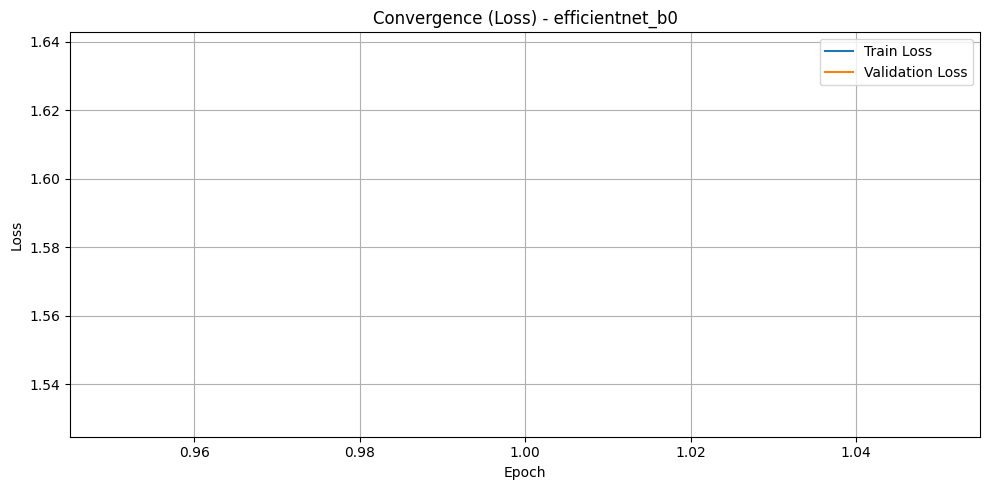

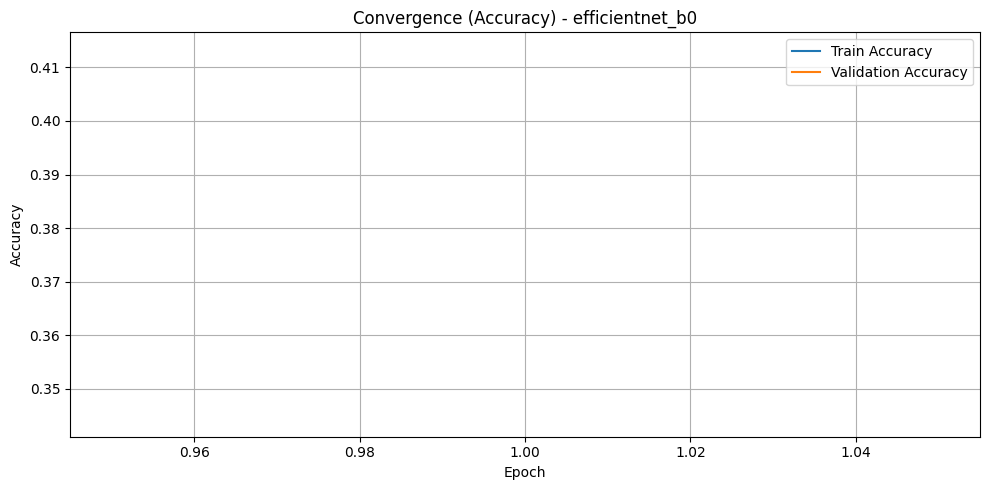

Saved plots for efficientnet_b0


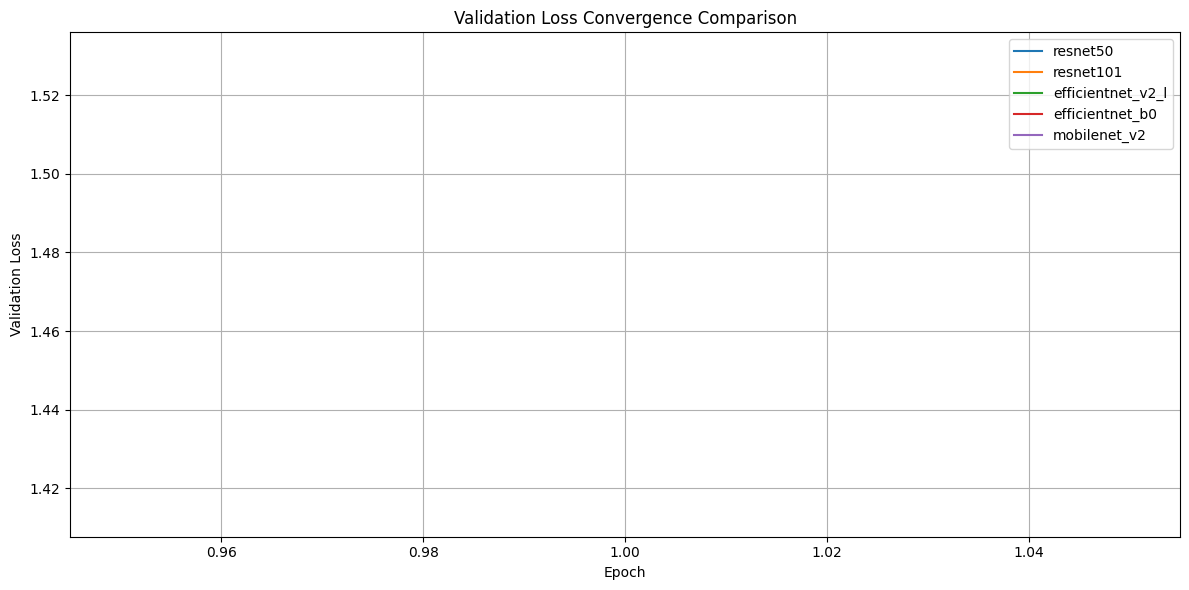

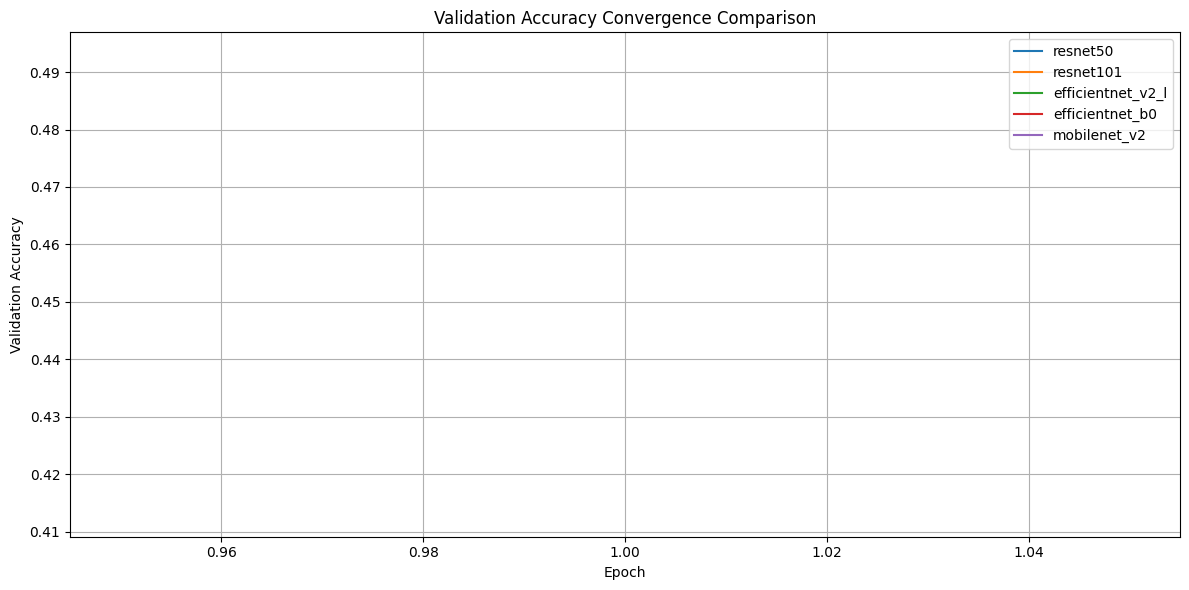

In [40]:
model_names = [
    "resnet50",
    "resnet101",
    "efficientnet_v2_l",
    "efficientnet_b0",
    "mobilenet_v2",
]

# single model
plot_convergence("efficientnet_b0", "/kaggle/working/", max_epochs=30)

# compare all
compare_convergence(model_names, "/kaggle/working/", max_epochs=30)

# Evaluation

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


# =========================
# Test evaluation function
# =========================

def evaluate_on_test_set(
    model,
    test_loader,
    device,
    class_names,
    output_dir,
    model_name="model"
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    num_classes = len(class_names)

    # =========================
    # Overall metrics
    # =========================

    accuracy = accuracy_score(all_labels, all_preds)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    recall_macro = recall_score(all_labels, all_preds, average="macro")
    recall_weighted = recall_score(all_labels, all_preds, average="weighted")

    precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    precision_weighted = precision_score(all_labels, all_preds, average="weighted", zero_division=0)

    # ROC-AUC
    try:
        if num_classes == 2:
            roc_auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            roc_auc = roc_auc_score(
                all_labels,
                all_probs,
                multi_class="ovr",
                average="macro"
            )
    except Exception as e:
        print("ROC-AUC could not be calculated:", e)
        roc_auc = np.nan

    metrics_df = pd.DataFrame([{
        "model_name": model_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "roc_auc_ovr_macro": roc_auc
    }])

    metrics_path = output_dir / f"{model_name}_test_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)

    print(f"Saved test metrics to: {metrics_path}")
    print(metrics_df)

    # =========================
    # Per-class classification report
    # =========================

    report_dict = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_path = output_dir / f"{model_name}_classification_report.csv"
    report_df.to_csv(report_path)

    print(f"Saved classification report to: {report_path}")

    # =========================
    # Prediction probabilities CSV
    # =========================

    prob_df = pd.DataFrame(all_probs, columns=[f"prob_{c}" for c in class_names])
    pred_df = pd.DataFrame({
        "true_label_id": all_labels,
        "pred_label_id": all_preds,
        "true_class": [class_names[i] for i in all_labels],
        "pred_class": [class_names[i] for i in all_preds],
        "confidence": np.max(all_probs, axis=1)
    })

    prediction_df = pd.concat([pred_df, prob_df], axis=1)
    prediction_path = output_dir / f"{model_name}_test_predictions.csv"
    prediction_df.to_csv(prediction_path, index=False)

    print(f"Saved test predictions to: {prediction_path}")

    # =========================
    # Confusion matrix
    # =========================

    cm = confusion_matrix(all_labels, all_preds)

    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_path = output_dir / f"{model_name}_confusion_matrix.csv"
    cm_df.to_csv(cm_path)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    cm_plot_path = output_dir / f"{model_name}_confusion_matrix.png"
    plt.savefig(cm_plot_path, dpi=300)
    plt.show()

    print(f"Saved confusion matrix plot to: {cm_plot_path}")

    # =========================
    # Normalized confusion matrix
    # =========================

    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    cm_norm_df = pd.DataFrame(
        cm_norm,
        index=class_names,
        columns=class_names
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm_df,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(f"Normalized Confusion Matrix - {model_name}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    cm_norm_plot_path = output_dir / f"{model_name}_normalized_confusion_matrix.png"
    plt.savefig(cm_norm_plot_path, dpi=300)
    plt.show()

    print(f"Saved normalized confusion matrix plot to: {cm_norm_plot_path}")

    # =========================
    # Per-class score visualization
    # =========================

    per_class_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]
    per_class_score_path = output_dir / f"{model_name}_per_class_scores.csv"
    per_class_df.to_csv(per_class_score_path)

    per_class_df[["precision", "recall", "f1-score"]].plot(
        kind="bar",
        figsize=(14, 7)
    )
    plt.title(f"Per-Class Precision, Recall, F1 Score - {model_name}")
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    score_plot_path = output_dir / f"{model_name}_per_class_scores.png"
    plt.savefig(score_plot_path, dpi=300)
    plt.show()

    print(f"Saved per-class score plot to: {score_plot_path}")

    # =========================
    # ROC curve
    # =========================

    plt.figure(figsize=(10, 8))

    if num_classes == 2:
        fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
        roc_auc_binary = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{class_names[1]} AUC = {roc_auc_binary:.4f}")

    else:
        y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

        for i, class_name in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
            class_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_name} AUC = {class_auc:.4f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC-AUC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()

    roc_plot_path = output_dir / f"{model_name}_roc_auc_curve.png"
    plt.savefig(roc_plot_path, dpi=300)
    plt.show()

    print(f"Saved ROC-AUC curve to: {roc_plot_path}")

    return {
        "metrics_df": metrics_df,
        "classification_report_df": report_df,
        "predictions_df": prediction_df,
        "confusion_matrix_df": cm_df,
        "per_class_df": per_class_df
    }


Evaluating resnet50
Saved test metrics to: /kaggle/working/evaluation_on_test_set/resnet50_test_metrics.csv
  model_name  accuracy  balanced_accuracy  f1_macro  f1_weighted  \
0   resnet50  0.460103           0.172885   0.15848     0.421366   

   recall_macro  recall_weighted  precision_macro  precision_weighted  \
0      0.172885         0.460103         0.154092            0.409311   

   roc_auc_ovr_macro  
0           0.476265  
Saved classification report to: /kaggle/working/evaluation_on_test_set/resnet50_classification_report.csv
Saved test predictions to: /kaggle/working/evaluation_on_test_set/resnet50_test_predictions.csv


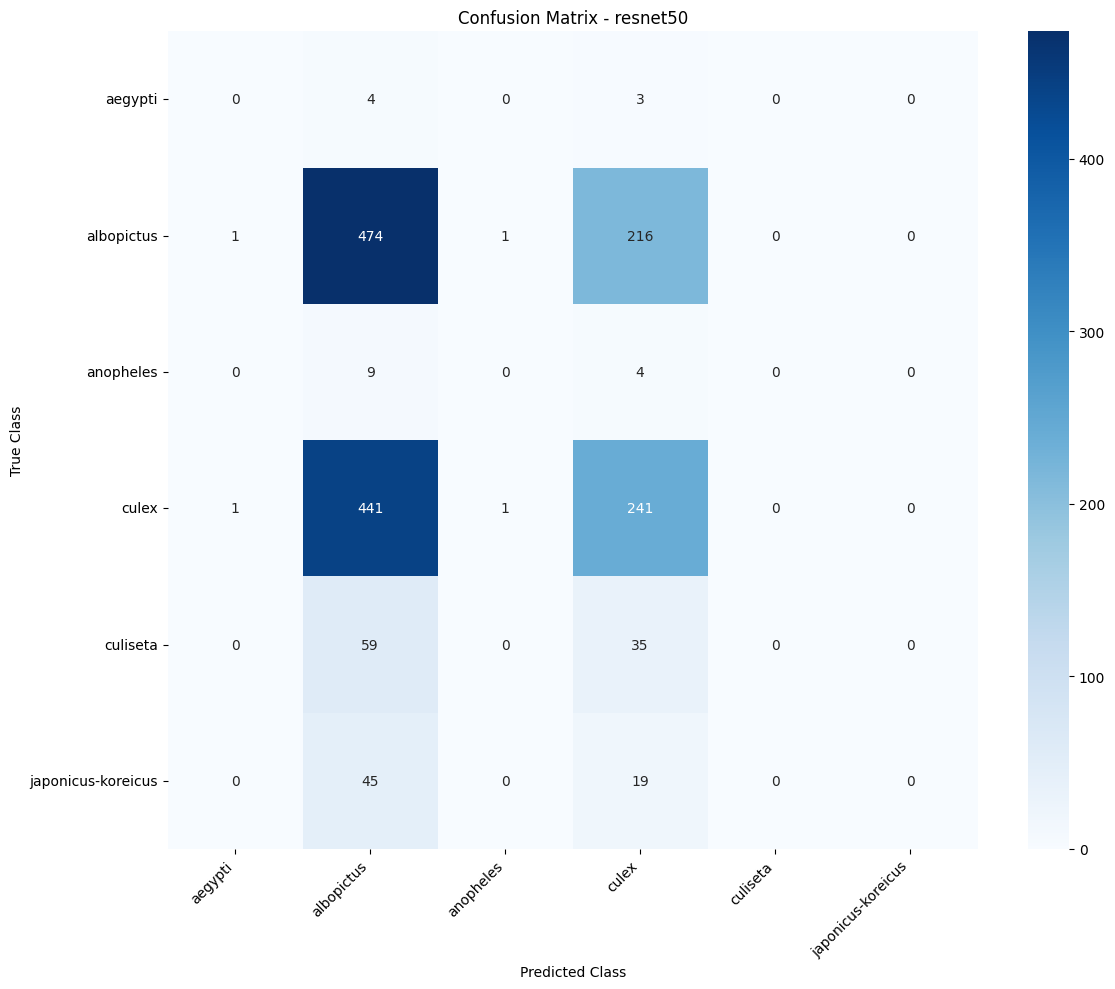

Saved confusion matrix plot to: /kaggle/working/evaluation_on_test_set/resnet50_confusion_matrix.png


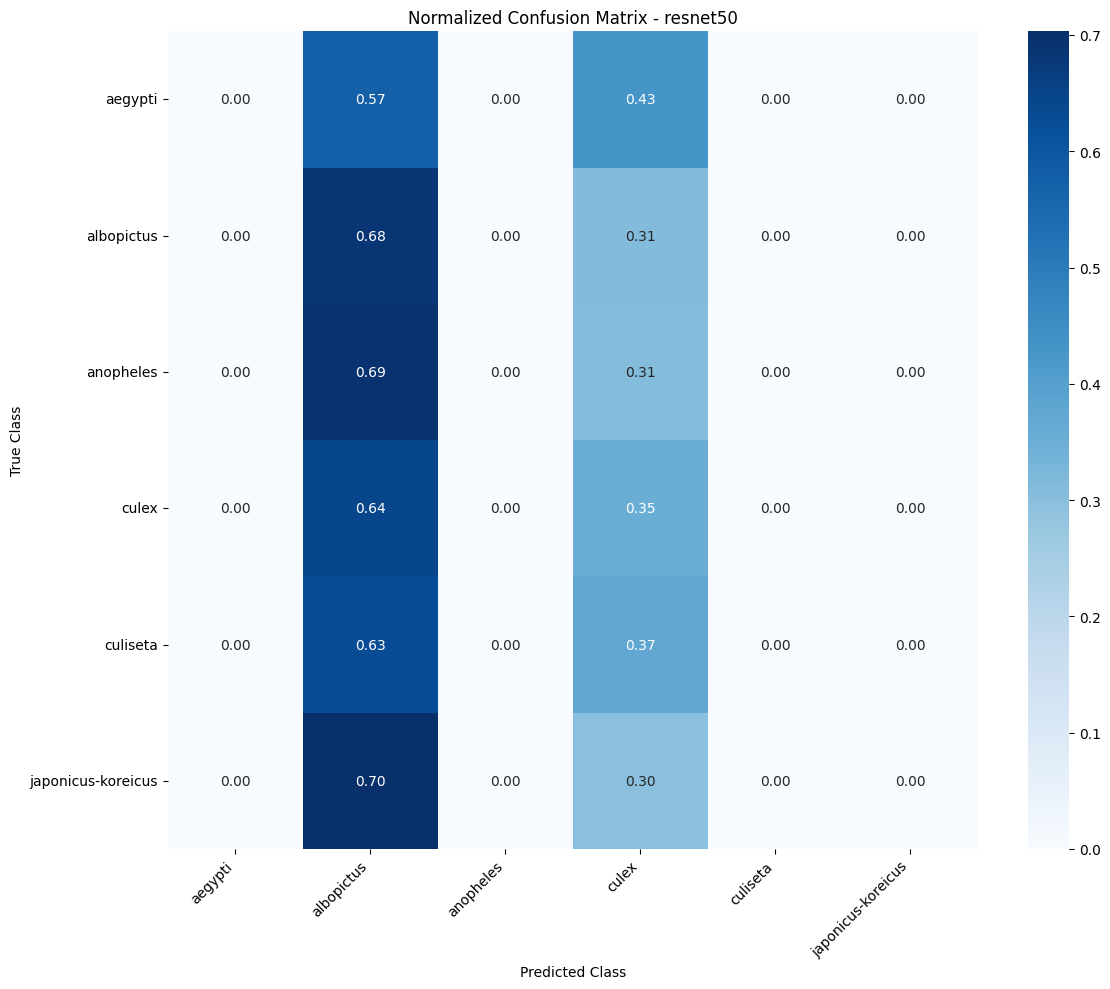

Saved normalized confusion matrix plot to: /kaggle/working/evaluation_on_test_set/resnet50_normalized_confusion_matrix.png


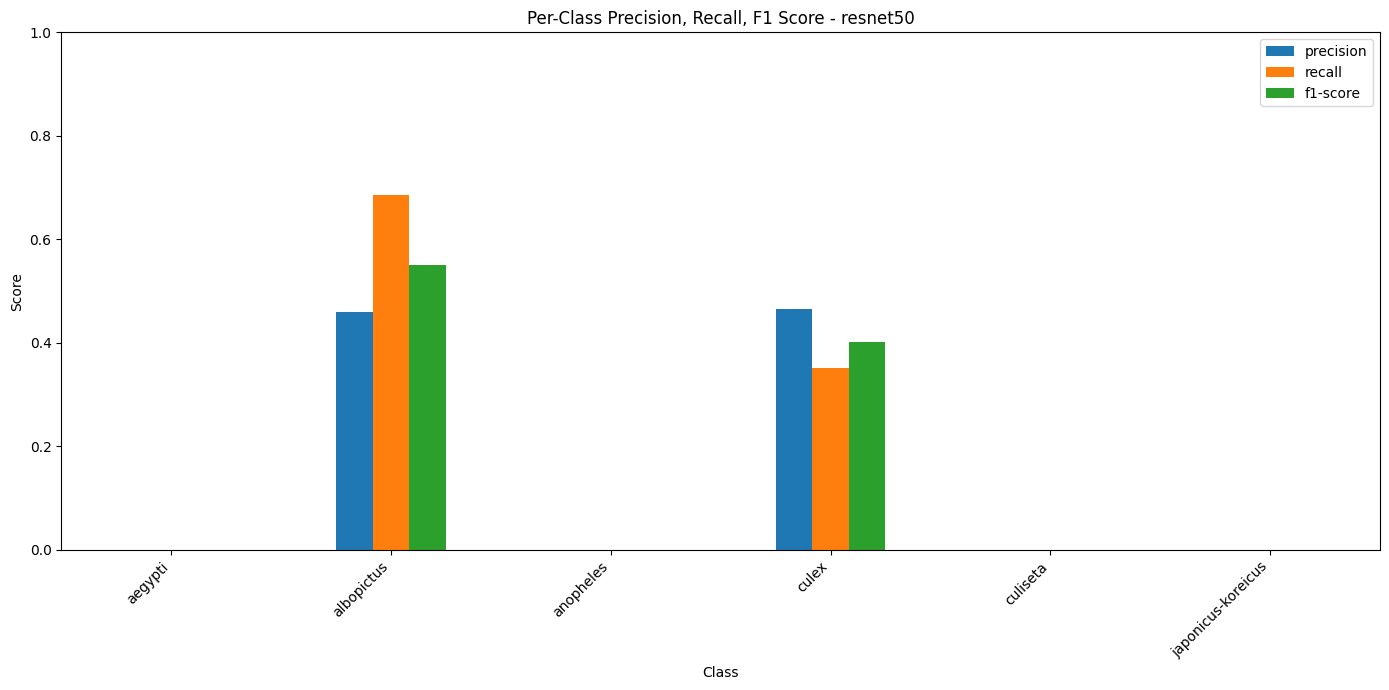

Saved per-class score plot to: /kaggle/working/evaluation_on_test_set/resnet50_per_class_scores.png


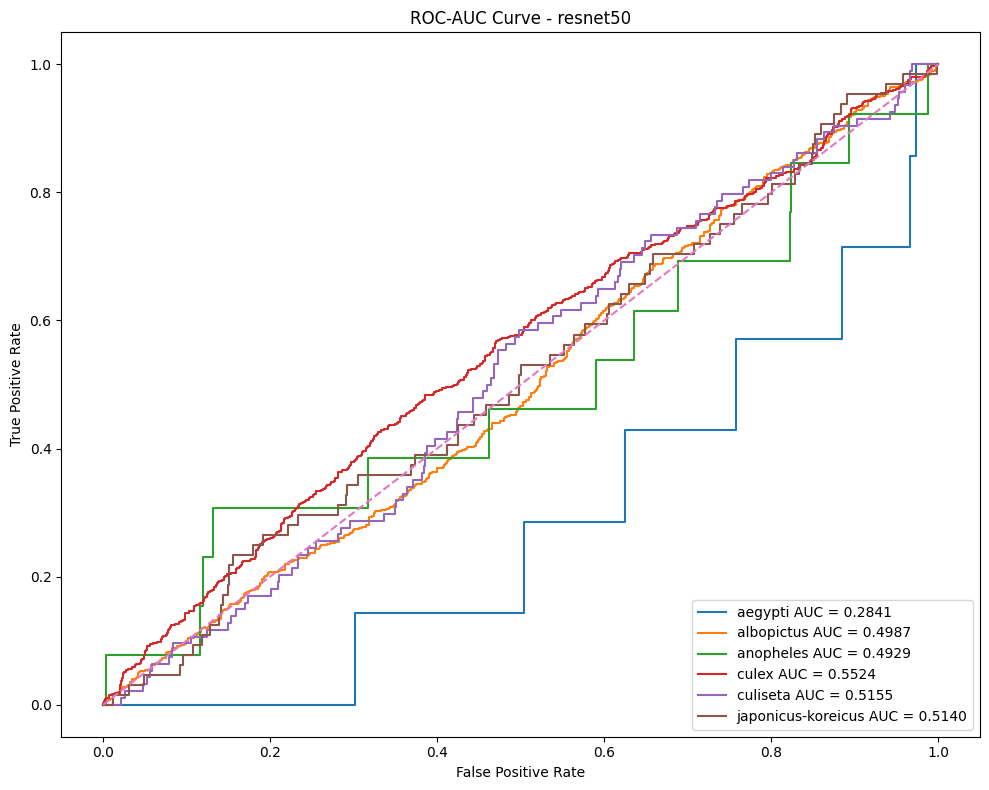

Saved ROC-AUC curve to: /kaggle/working/evaluation_on_test_set/resnet50_roc_auc_curve.png

Evaluating resnet101
Saved test metrics to: /kaggle/working/evaluation_on_test_set/resnet101_test_metrics.csv
  model_name  accuracy  balanced_accuracy  f1_macro  f1_weighted  \
0  resnet101  0.451737            0.17074   0.13832     0.366536   

   recall_macro  recall_weighted  precision_macro  precision_weighted  \
0       0.17074         0.451737         0.155837            0.414073   

   roc_auc_ovr_macro  
0           0.524642  
Saved classification report to: /kaggle/working/evaluation_on_test_set/resnet101_classification_report.csv
Saved test predictions to: /kaggle/working/evaluation_on_test_set/resnet101_test_predictions.csv


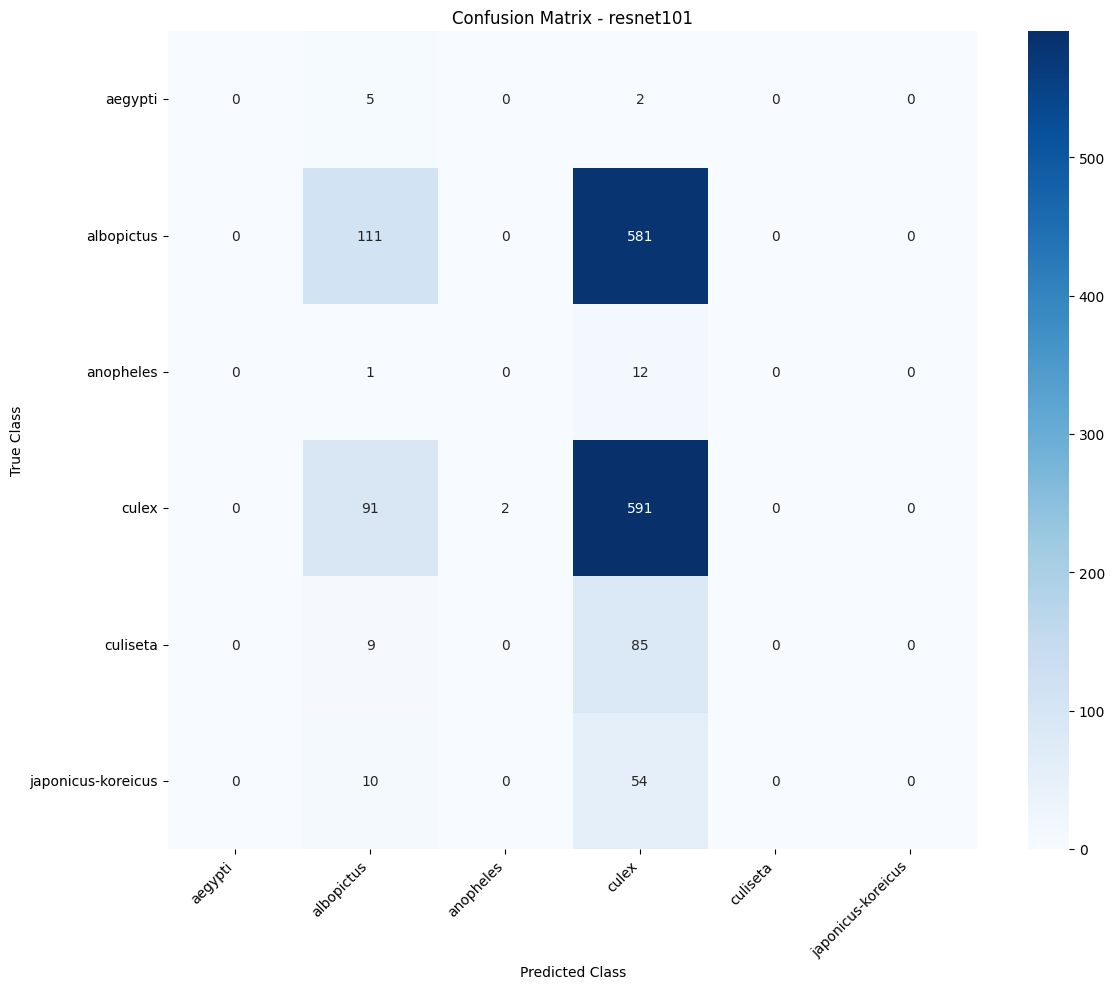

Saved confusion matrix plot to: /kaggle/working/evaluation_on_test_set/resnet101_confusion_matrix.png


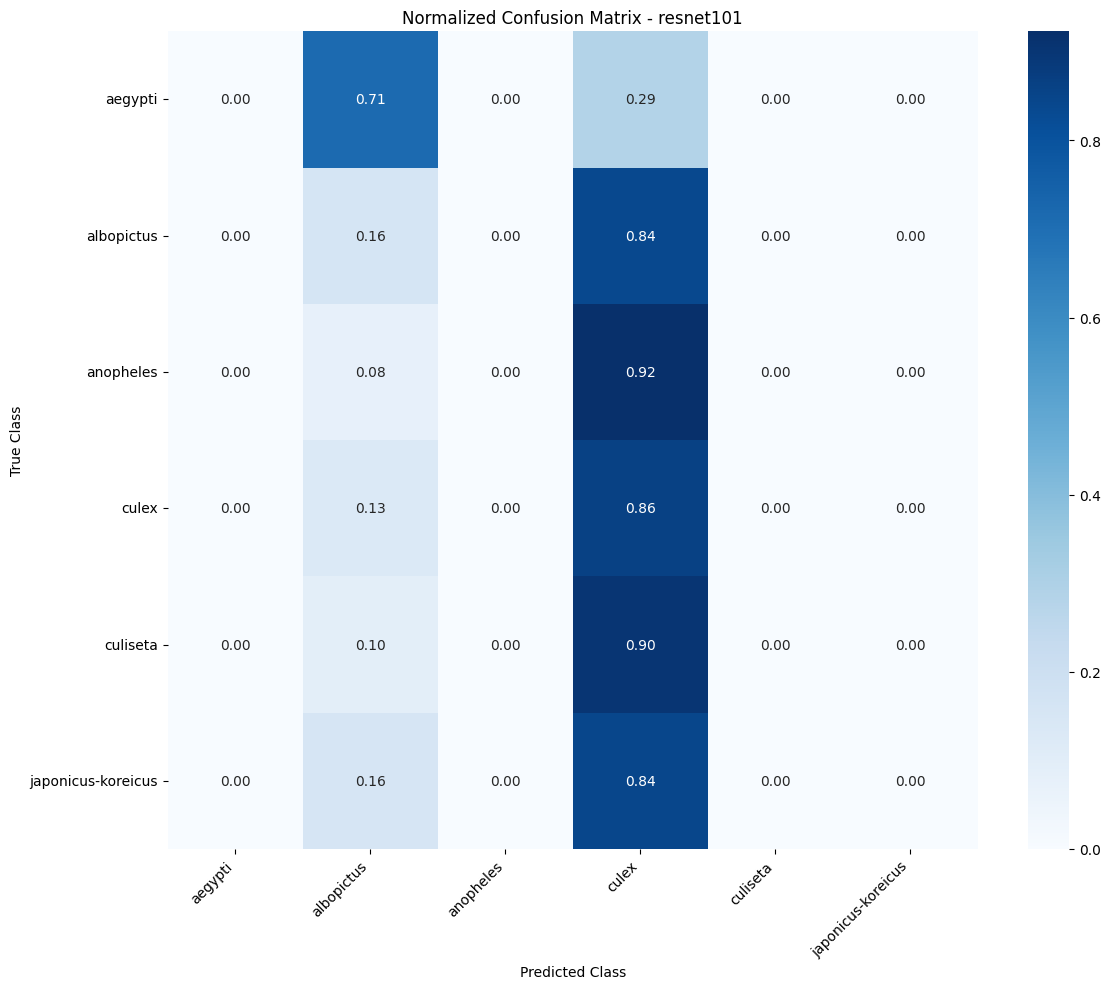

Saved normalized confusion matrix plot to: /kaggle/working/evaluation_on_test_set/resnet101_normalized_confusion_matrix.png


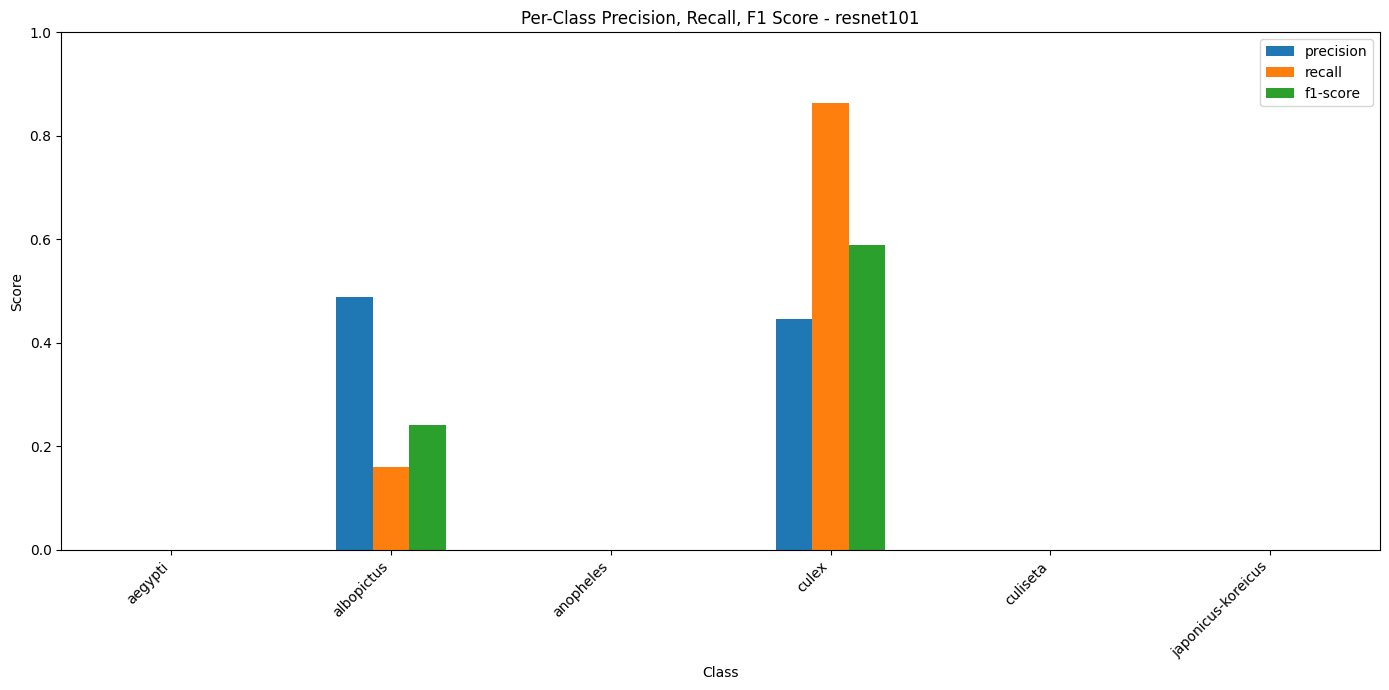

Saved per-class score plot to: /kaggle/working/evaluation_on_test_set/resnet101_per_class_scores.png


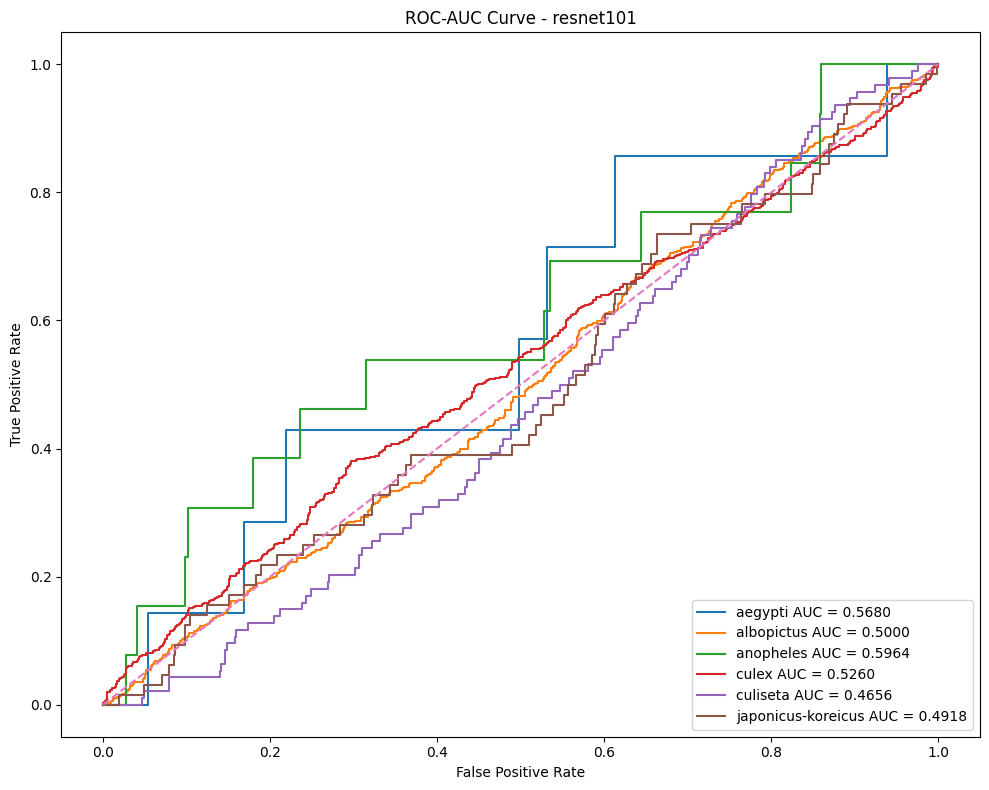

Saved ROC-AUC curve to: /kaggle/working/evaluation_on_test_set/resnet101_roc_auc_curve.png

Evaluating efficientnet_v2_l
Saved test metrics to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_test_metrics.csv
          model_name  accuracy  balanced_accuracy  f1_macro  f1_weighted  \
0  efficientnet_v2_l  0.454311            0.18237  0.177032     0.424479   

   recall_macro  recall_weighted  precision_macro  precision_weighted  \
0       0.18237         0.454311         0.199567            0.428226   

   roc_auc_ovr_macro  
0           0.466159  
Saved classification report to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_classification_report.csv
Saved test predictions to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_test_predictions.csv


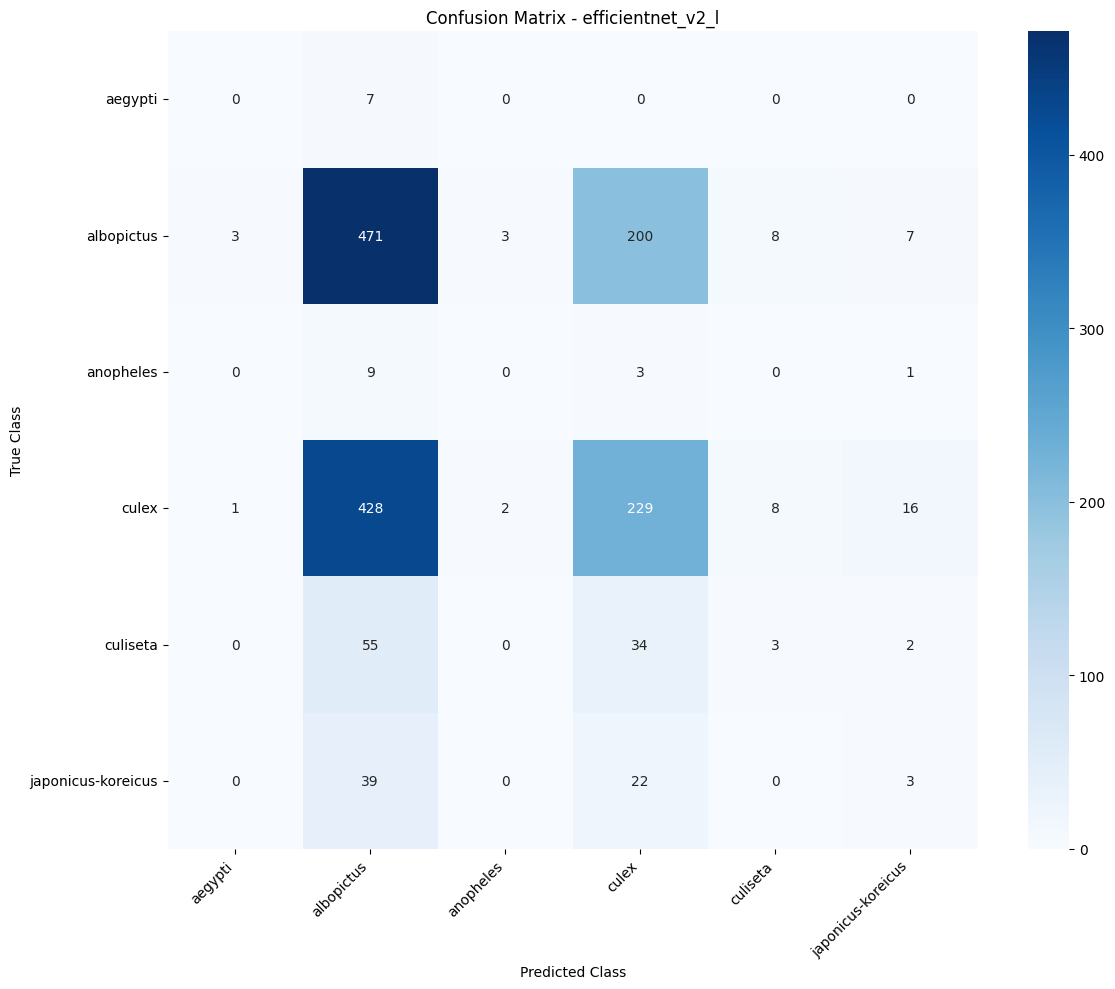

Saved confusion matrix plot to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_confusion_matrix.png


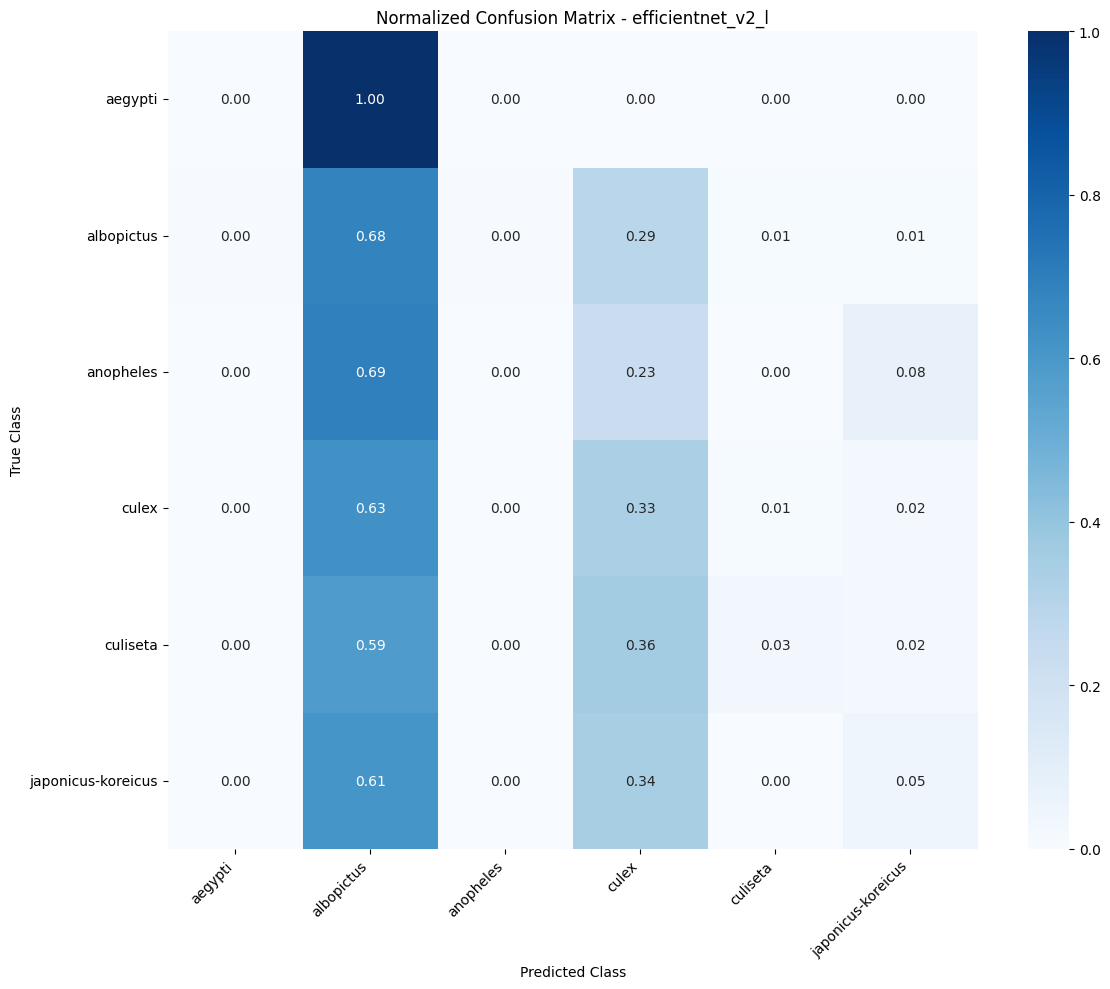

Saved normalized confusion matrix plot to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_normalized_confusion_matrix.png


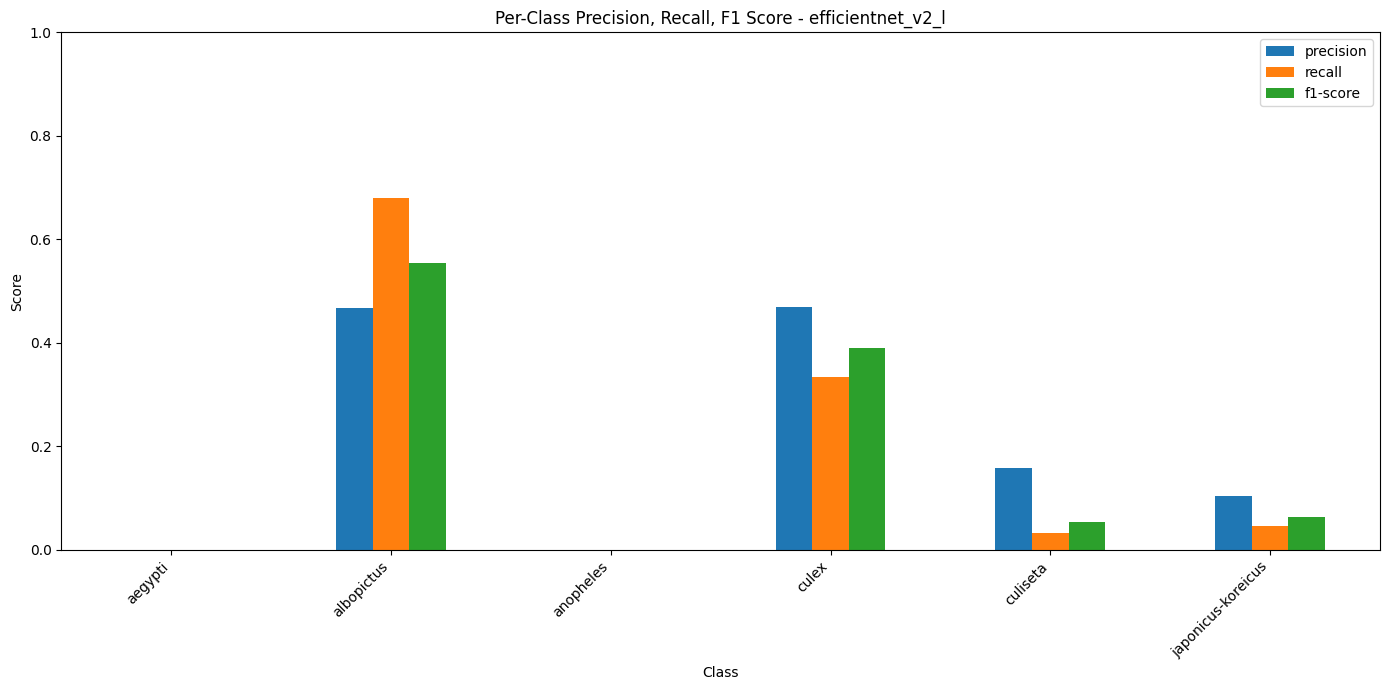

Saved per-class score plot to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_per_class_scores.png


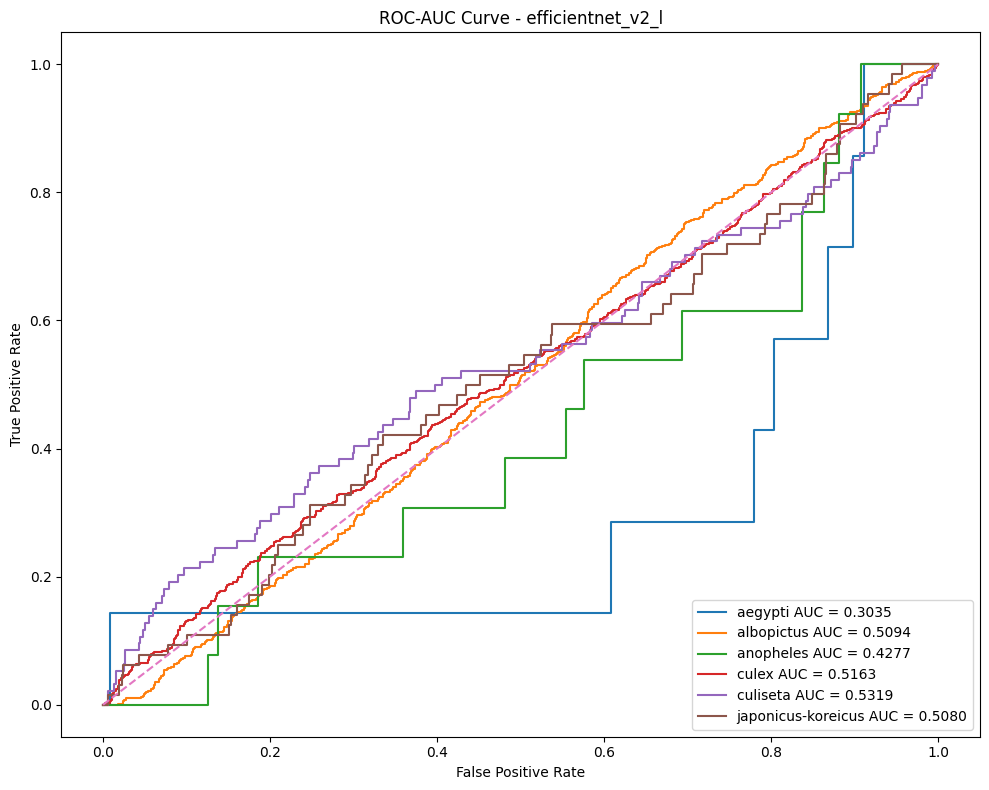

Saved ROC-AUC curve to: /kaggle/working/evaluation_on_test_set/efficientnet_v2_l_roc_auc_curve.png

Evaluating efficientnet_b0
Saved test metrics to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_test_metrics.csv
        model_name  accuracy  balanced_accuracy  f1_macro  f1_weighted  \
0  efficientnet_b0  0.400901           0.157267  0.153397      0.38624   

   recall_macro  recall_weighted  precision_macro  precision_weighted  \
0      0.157267         0.400901         0.155966            0.384885   

   roc_auc_ovr_macro  
0           0.481451  
Saved classification report to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_classification_report.csv
Saved test predictions to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_test_predictions.csv


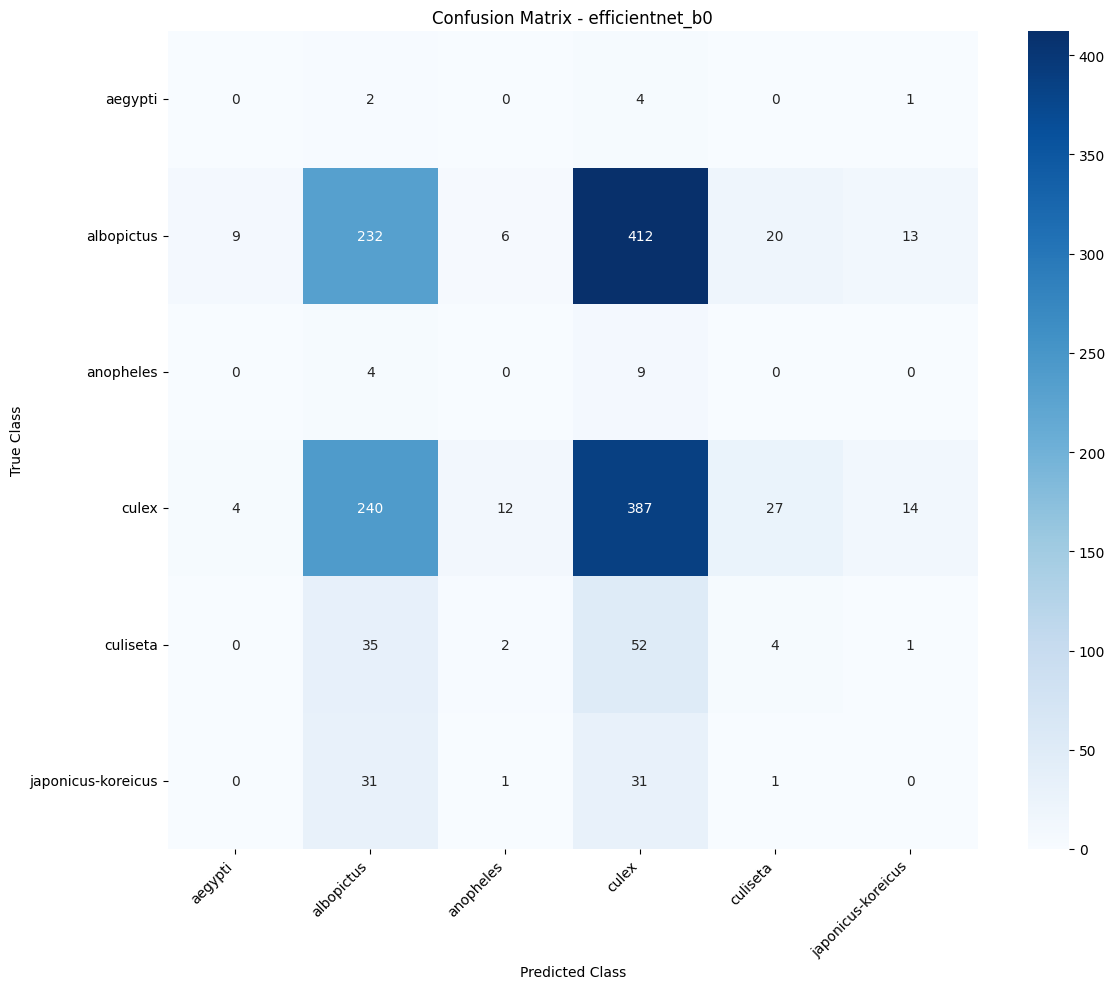

Saved confusion matrix plot to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_confusion_matrix.png


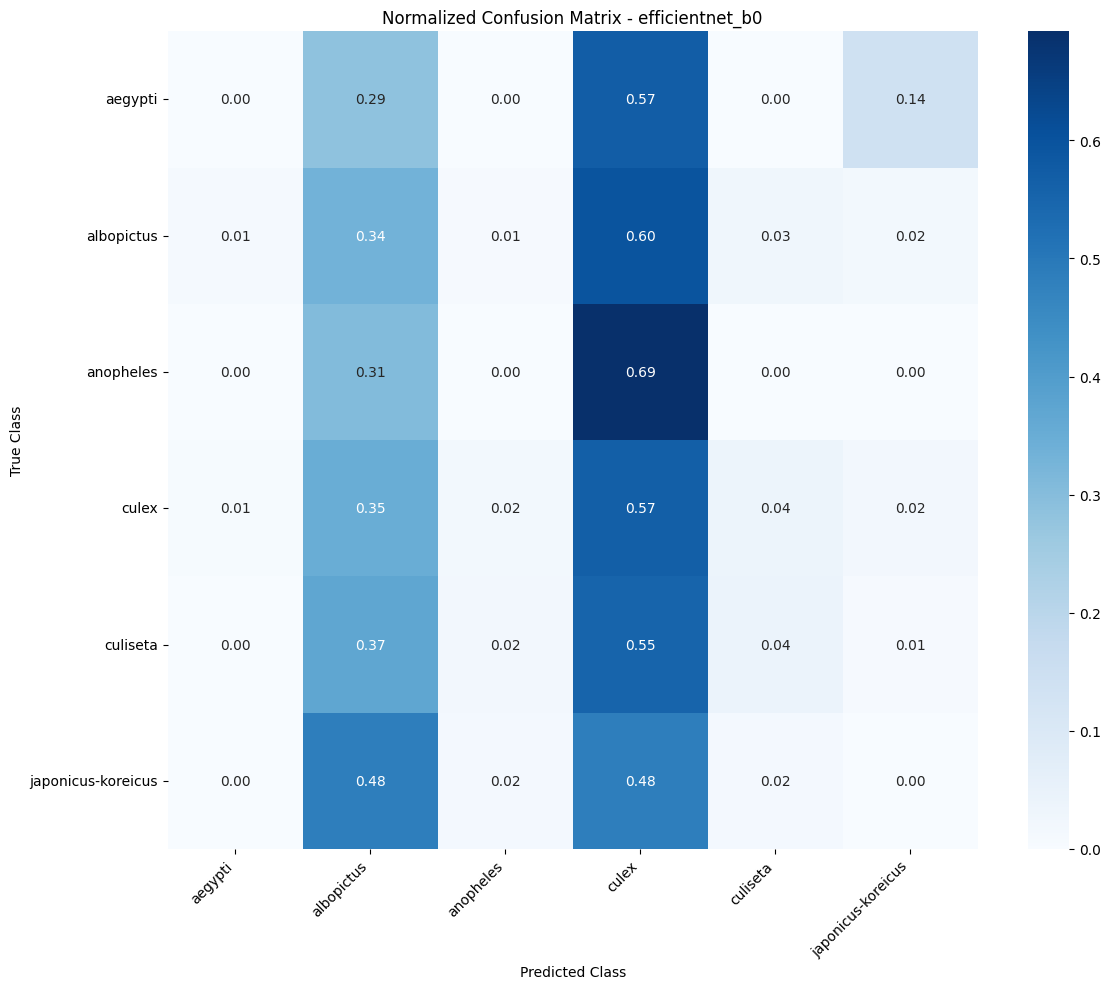

Saved normalized confusion matrix plot to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_normalized_confusion_matrix.png


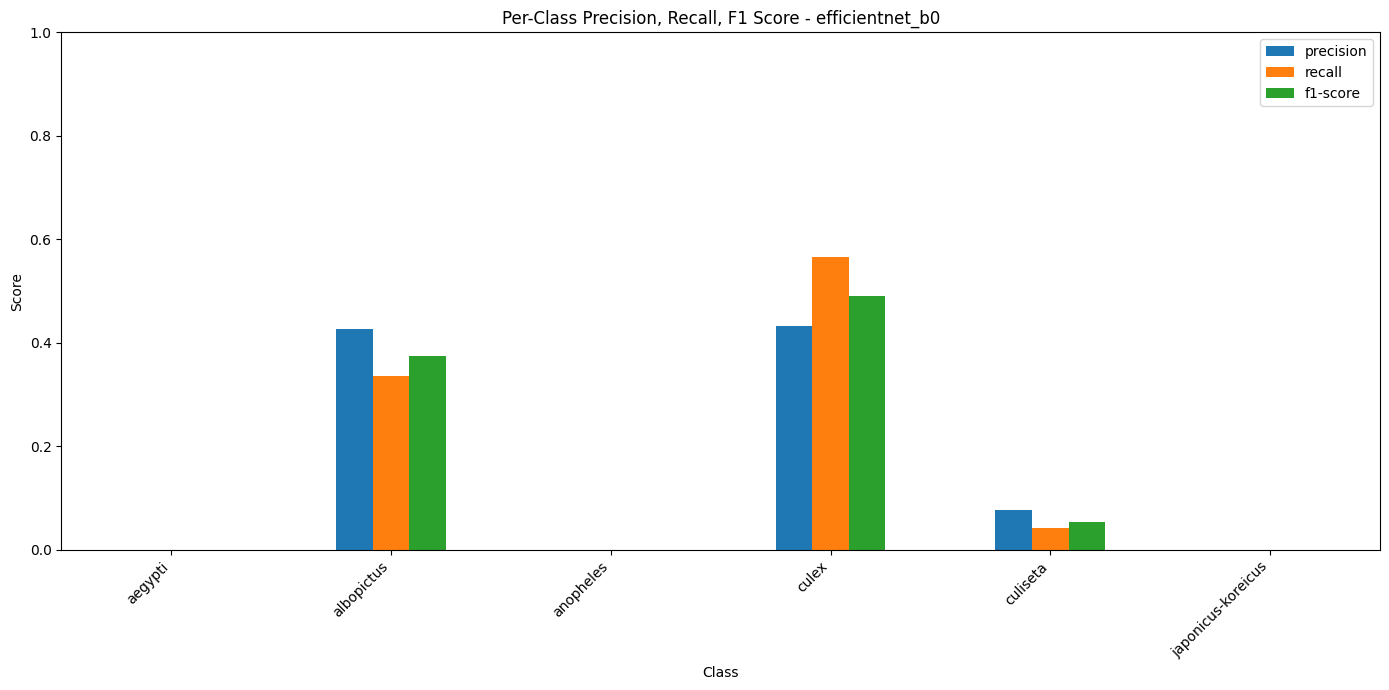

Saved per-class score plot to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_per_class_scores.png


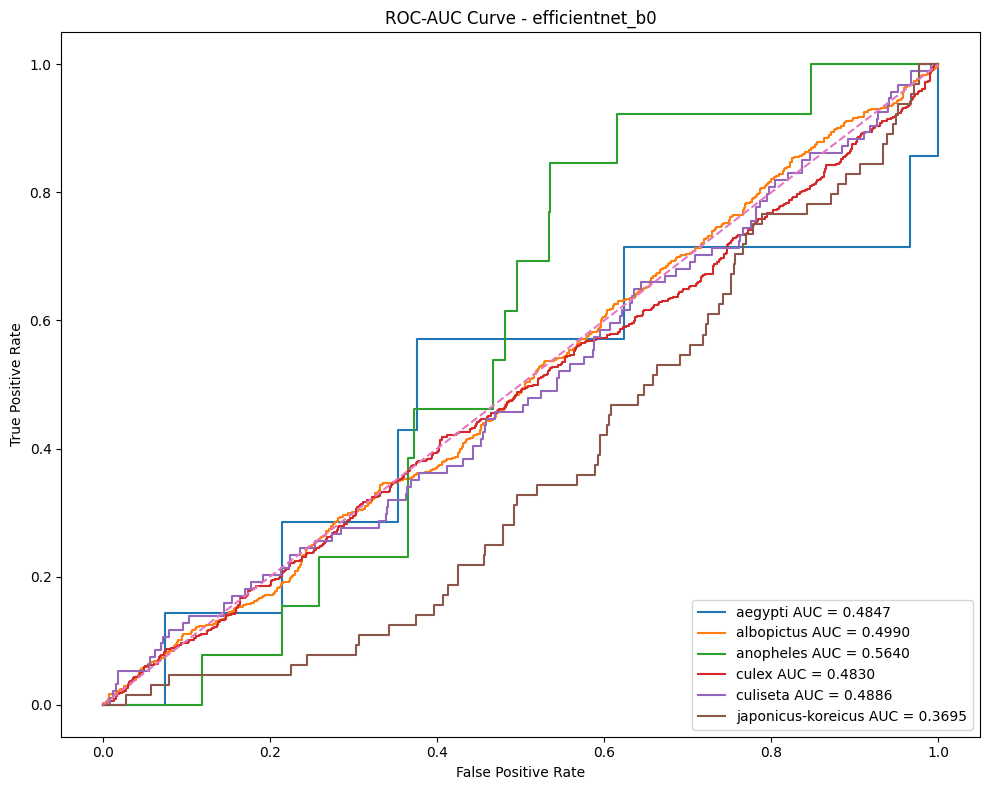

Saved ROC-AUC curve to: /kaggle/working/evaluation_on_test_set/efficientnet_b0_roc_auc_curve.png

Evaluating mobilenet_v2
Saved test metrics to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_test_metrics.csv
     model_name  accuracy  balanced_accuracy  f1_macro  f1_weighted  \
0  mobilenet_v2  0.508366           0.191281  0.179383     0.476616   

   recall_macro  recall_weighted  precision_macro  precision_weighted  \
0      0.191281         0.508366         0.169479            0.450196   

   roc_auc_ovr_macro  
0           0.512139  
Saved classification report to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_classification_report.csv
Saved test predictions to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_test_predictions.csv


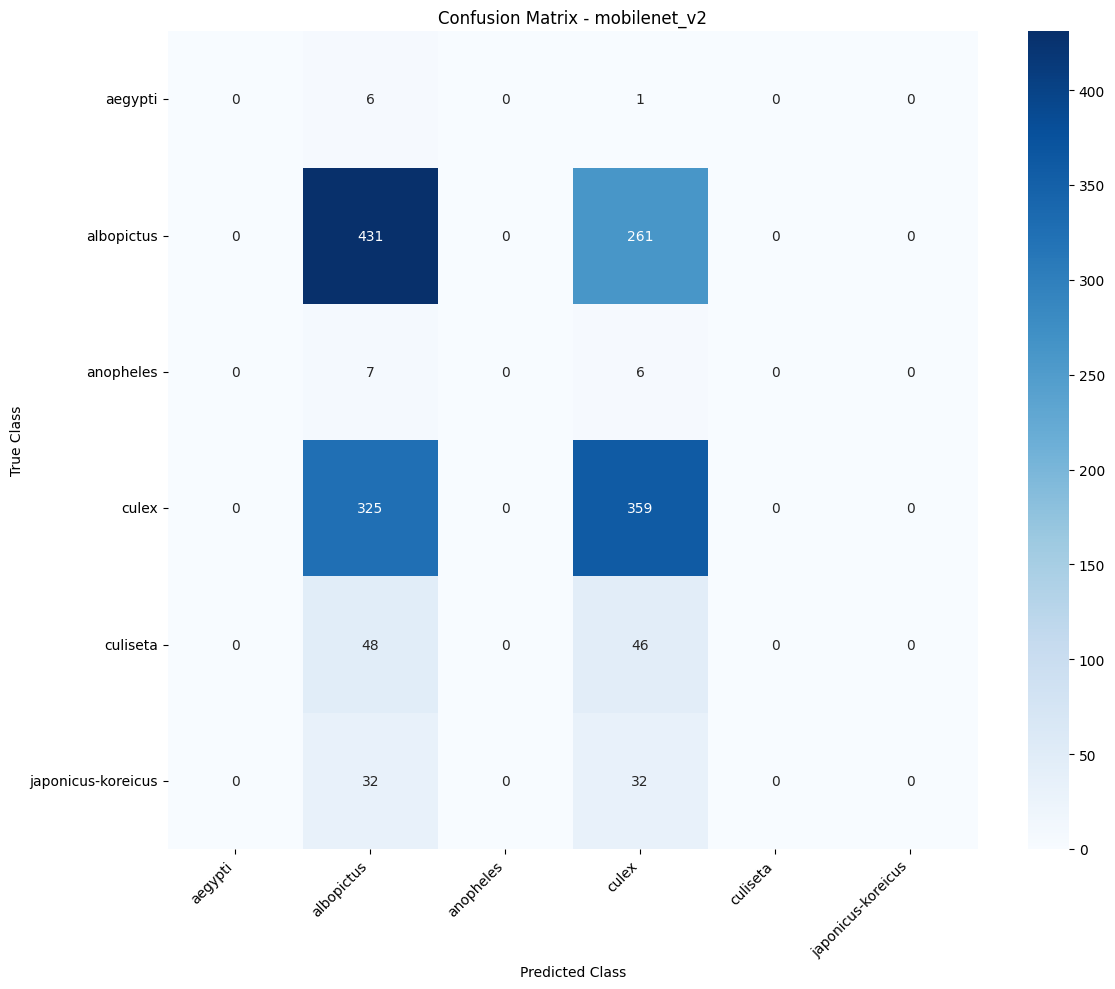

Saved confusion matrix plot to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_confusion_matrix.png


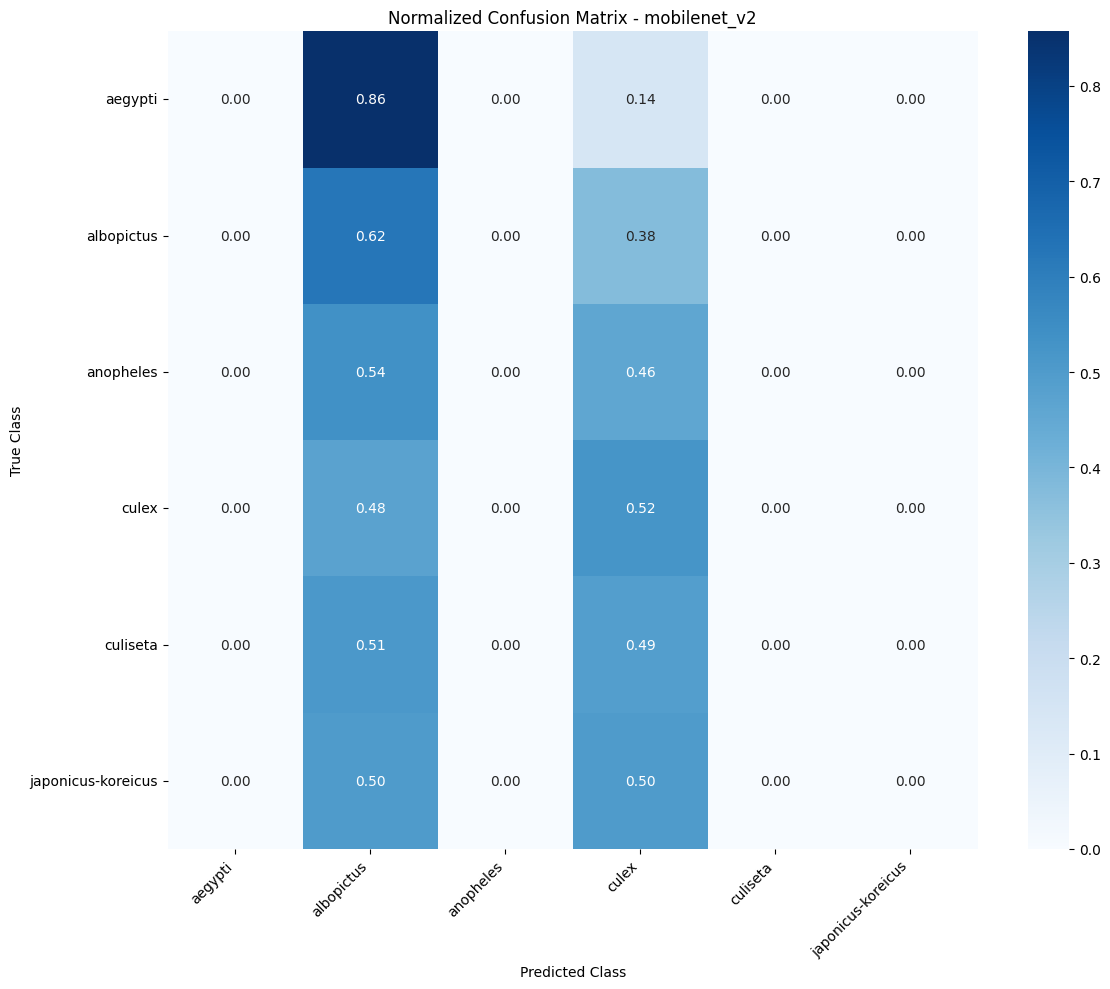

Saved normalized confusion matrix plot to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_normalized_confusion_matrix.png


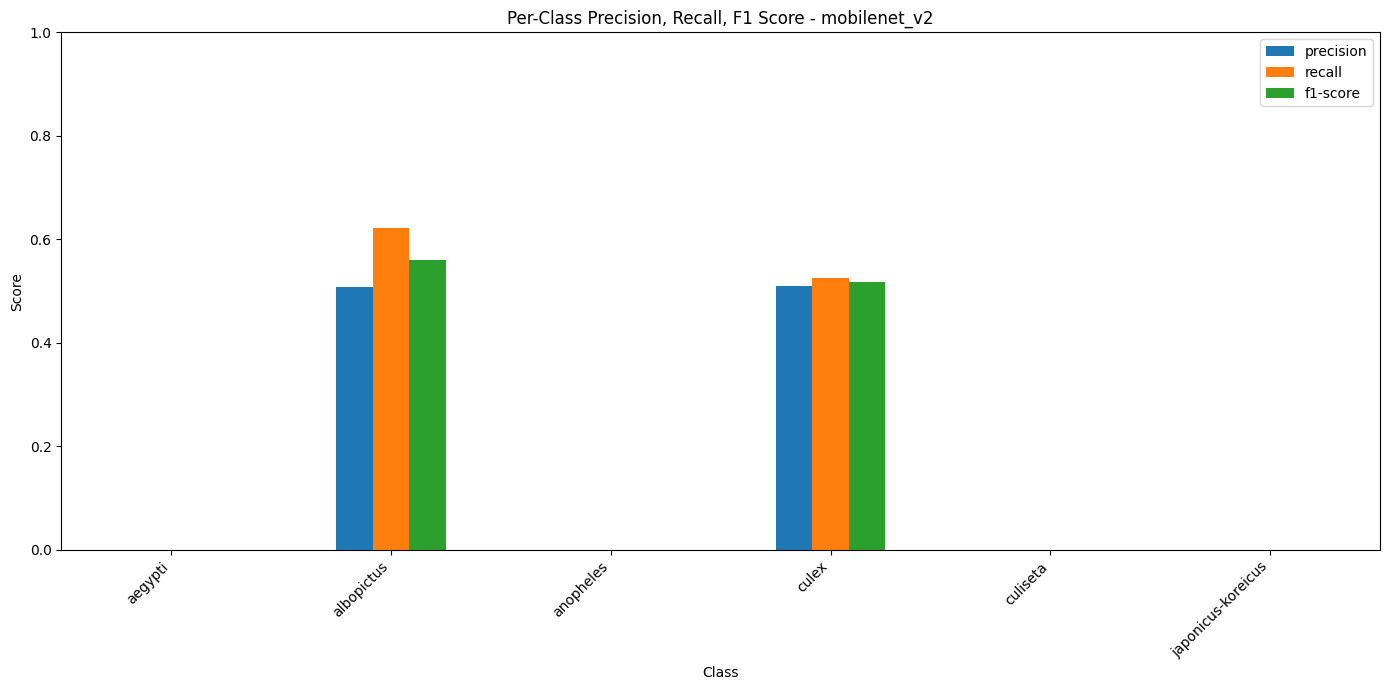

Saved per-class score plot to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_per_class_scores.png


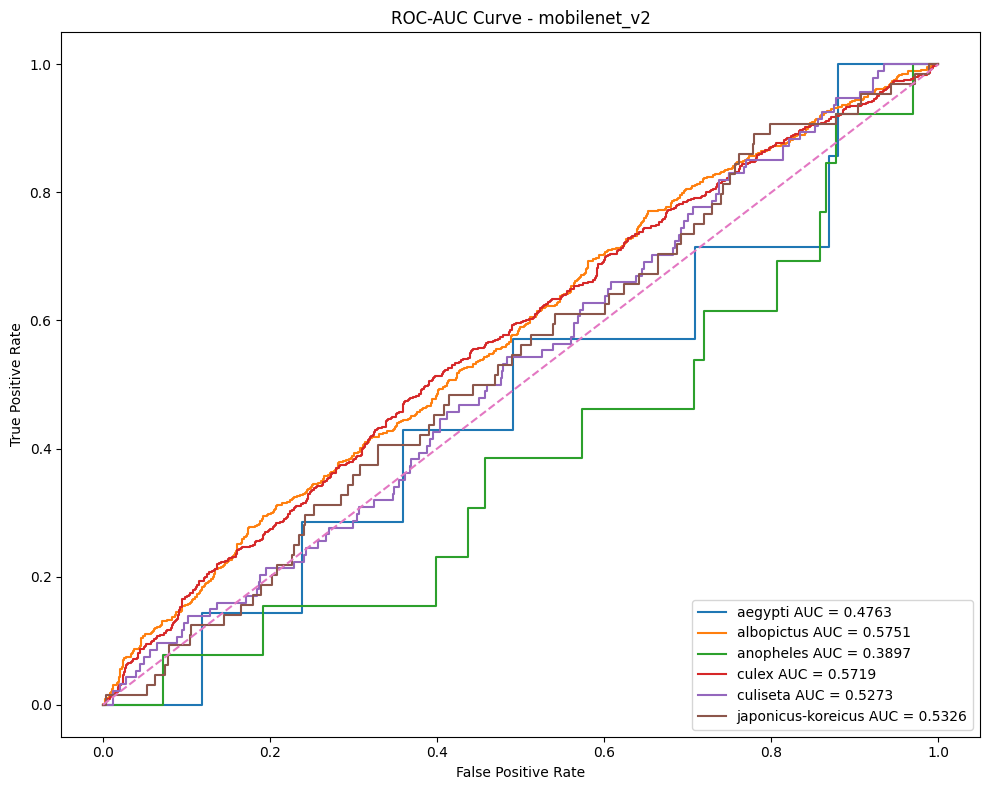

Saved ROC-AUC curve to: /kaggle/working/evaluation_on_test_set/mobilenet_v2_roc_auc_curve.png

All model evaluation completed.
Saved summary to: /kaggle/working/evaluation_on_test_set/all_models_test_evaluation_summary.csv


,model_name,accuracy,balanced_accuracy,f1_macro,f1_weighted,recall_macro,recall_weighted,precision_macro,precision_weighted,roc_auc_ovr_macro
0,resnet50,0.460103,0.172885,0.158480,0.421366,0.172885,0.460103,0.154092,0.409311,0.476265
1,resnet101,0.451737,0.170740,0.138320,0.366536,0.170740,0.451737,0.155837,0.414073,0.524642
2,efficientnet_v2_l,0.454311,0.182370,0.177032,0.424479,0.182370,0.454311,0.199567,0.428226,0.466159
3,efficientnet_b0,0.400901,0.157267,0.153397,0.386240,0.157267,0.400901,0.155966,0.384885,0.481451
4,mobilenet_v2,0.508366,0.191281,0.179383,0.476616,0.191281,0.508366,0.169479,0.450196,0.512139


In [37]:
output_dir = Path("/kaggle/working/")
eval_output_dir = output_dir / "evaluation_on_test_set"
eval_output_dir.mkdir(parents=True, exist_ok=True)

model_names = [
    "resnet50",
    "resnet101",
    "efficientnet_v2_l",
    "efficientnet_b0",
    "mobilenet_v2",
]

all_test_metrics = []

for model_name in model_names:
    print(f"\nEvaluating {model_name}")

    # Rebuild model architecture
    model = build_model(
        model_name=model_name,
        num_classes=num_classes,
        freeze_backbone=True
    ).to(device)

    # Load best checkpoint
    checkpoint_path = output_dir / f"best_{model_name}.pth"
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    # Evaluate
    results = evaluate_on_test_set(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names,
        output_dir=eval_output_dir,
        model_name=model_name
    )

    # Collect overall metrics
    metrics_df = results["metrics_df"]
    all_test_metrics.append(metrics_df)

# Combine all model test results
all_test_metrics_df = pd.concat(all_test_metrics, ignore_index=True)

summary_path = eval_output_dir / "all_models_test_evaluation_summary.csv"
all_test_metrics_df.to_csv(summary_path, index=False)

print("\nAll model evaluation completed.")
print(f"Saved summary to: {summary_path}")

all_test_metrics_df